In [2]:

!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc


!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/24cd3016_HarshitaGupta_cnn_lab.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPU is available", gpus if gpus else "No GPU detected")

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2
GPU is available [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
(mnist_train_x, mnist_train_y), (mnist_test_x, mnist_test_y) = tf.keras.datasets.mnist.load_data()
(cifar_train_x, cifar_train_y), (cifar_test_x, cifar_test_y) = tf.keras.datasets.cifar10.load_data()

print("===== MNIST =====")
print("Train images shape:", mnist_train_x.shape)
print("Test images shape:", mnist_test_x.shape)
print("Train labels shape:", mnist_train_y.shape)
print("Data type:", mnist_train_x.dtype)
print("Pixel value range:", mnist_train_x.min(), "to", mnist_train_x.max())

print("\n===== CIFAR-10 =====")
print("Train images shape:", cifar_train_x.shape)
print("Test images shape:", cifar_test_x.shape)
print("Train labels shape:", cifar_train_y.shape)
print("Data type:", cifar_train_x.dtype)
print("Pixel value range:", cifar_train_x.min(), "to", cifar_train_x.max())

print("\n===== MNIST Class Distribution =====")
for i in range(10):
    count = np.sum(mnist_train_y == i)
    print(f"  Digit {i}: {count} samples")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
===== MNIST =====
Train images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)
Train labels shape: (60000,)
Data type: uint8
Pixel value range: 0 to 255

===== CIFAR-10 =====
Train images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)
Train labels shape: (50000, 1)
Data type: uint8
Pixel value range: 0 to 255

===== MNIST Class Distribution =====
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


MNIST: shape  1: train image (60000, 28, 28) , test image: (10000, 28, 28) .
CIFAR-10: shape 1: train image (50000, 32, 32, 3) , test image:(10000, 32, 32, 3). RGB, 3 channels.
Both datasets: dtype uint8, pixel range 0–255.

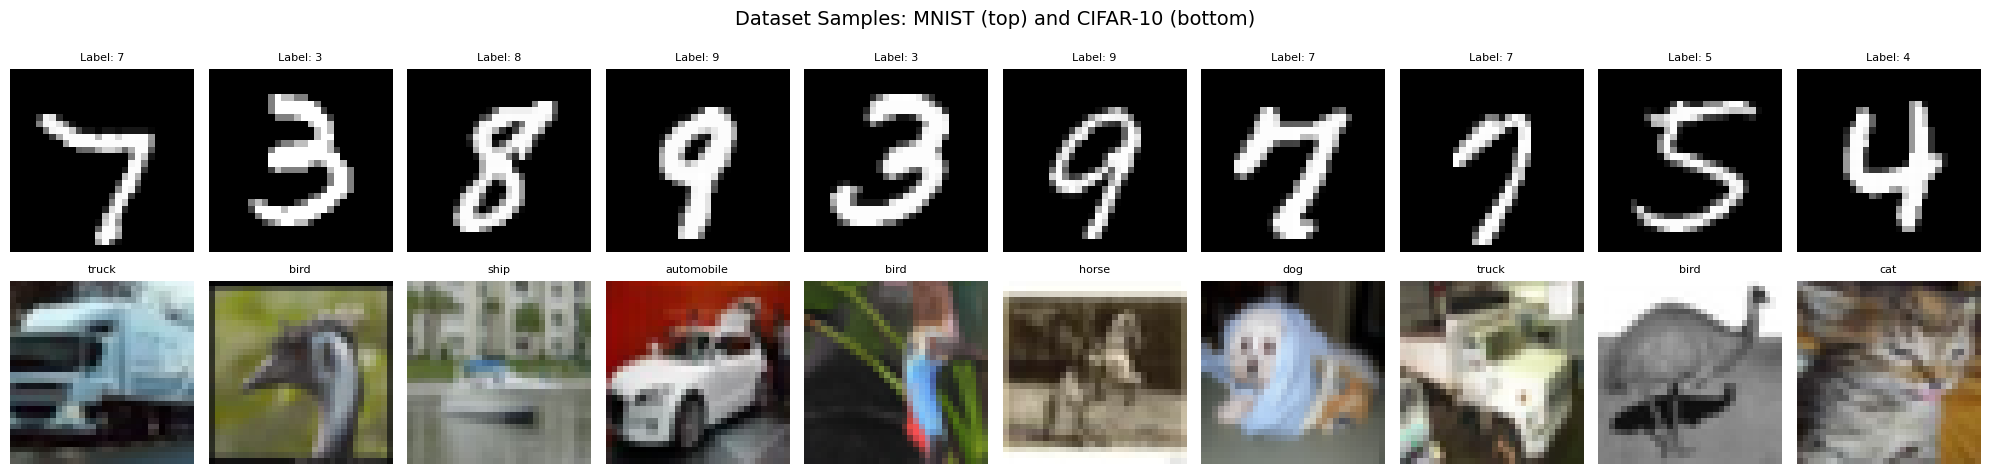

In [5]:
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Dataset Samples: MNIST (top) and CIFAR-10 (bottom)', fontsize=14)

random_mnist_idx = np.random.choice(len(mnist_train_x), 10, replace=False)
for i, idx in enumerate(random_mnist_idx):
    axes[0, i].imshow(mnist_train_x[idx], cmap='gray')
    axes[0, i].set_title(f'Label: {mnist_train_y[idx]}', fontsize=8)
    axes[0, i].axis('off')

random_cifar_idx = np.random.choice(len(cifar_train_x), 10, replace=False)
for i, idx in enumerate(random_cifar_idx):
    axes[1, i].imshow(cifar_train_x[idx])
    axes[1, i].set_title(cifar_classes[cifar_train_y[idx][0]], fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
def preprocess(images, labels, is_mnist=False):

    print("BEFORE preprocessing:")
    print("  Shape:", images.shape)
    print("  Dtype:", images.dtype)
    print("  Range:", images.min(), "to", images.max())

    images = (images / 255.0).astype(np.float32)
    print("\nAFTER normalization:")
    print("  Dtype:", images.dtype)
    print("  Range:", images.min(), "to", images.max())

    if is_mnist:
        images = images.reshape(-1, 28, 28, 1)
        print("\nAFTER reshape:")
        print("  Shape:", images.shape)

    labels = labels.flatten()
    labels = tf.keras.utils.to_categorical(labels, num_classes=10)
    print("\nAFTER one-hot encoding:")
    print("  Labels shape:", labels.shape)
    print("  Sample label:", labels[0])

    return images, labels

print("MNIST")
mnist_train_x_p, mnist_train_y_p = preprocess(mnist_train_x, mnist_train_y, is_mnist=True)
mnist_test_x_p, mnist_test_y_p = preprocess(mnist_test_x, mnist_test_y, is_mnist=True)

print("\nCIFAR-10")
cifar_train_x_p, cifar_train_y_p = preprocess(cifar_train_x, cifar_train_y, is_mnist=False)
cifar_test_x_p, cifar_test_y_p = preprocess(cifar_test_x, cifar_test_y, is_mnist=False)

MNIST
BEFORE preprocessing:
  Shape: (60000, 28, 28)
  Dtype: uint8
  Range: 0 to 255

AFTER normalization:
  Dtype: float32
  Range: 0.0 to 1.0

AFTER reshape:
  Shape: (60000, 28, 28, 1)

AFTER one-hot encoding:
  Labels shape: (60000, 10)
  Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
BEFORE preprocessing:
  Shape: (10000, 28, 28)
  Dtype: uint8
  Range: 0 to 255

AFTER normalization:
  Dtype: float32
  Range: 0.0 to 1.0

AFTER reshape:
  Shape: (10000, 28, 28, 1)

AFTER one-hot encoding:
  Labels shape: (10000, 10)
  Sample label: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

CIFAR-10
BEFORE preprocessing:
  Shape: (50000, 32, 32, 3)
  Dtype: uint8
  Range: 0 to 255

AFTER normalization:
  Dtype: float32
  Range: 0.0 to 1.0

AFTER one-hot encoding:
  Labels shape: (50000, 10)
  Sample label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
BEFORE preprocessing:
  Shape: (10000, 32, 32, 3)
  Dtype: uint8
  Range: 0 to 255

AFTER normalization:
  Dtype: float32
  Range: 0.0 to 1.0

AFTER one-hot encoding:
  Labe

Problem 3 observations:
- Before: dtype uint8, range 0-255
- After normalization: dtype float32, range 0.0-1.0
- MNIST reshaped from (N,28,28) to (N,28,28,1) to add channel dimension

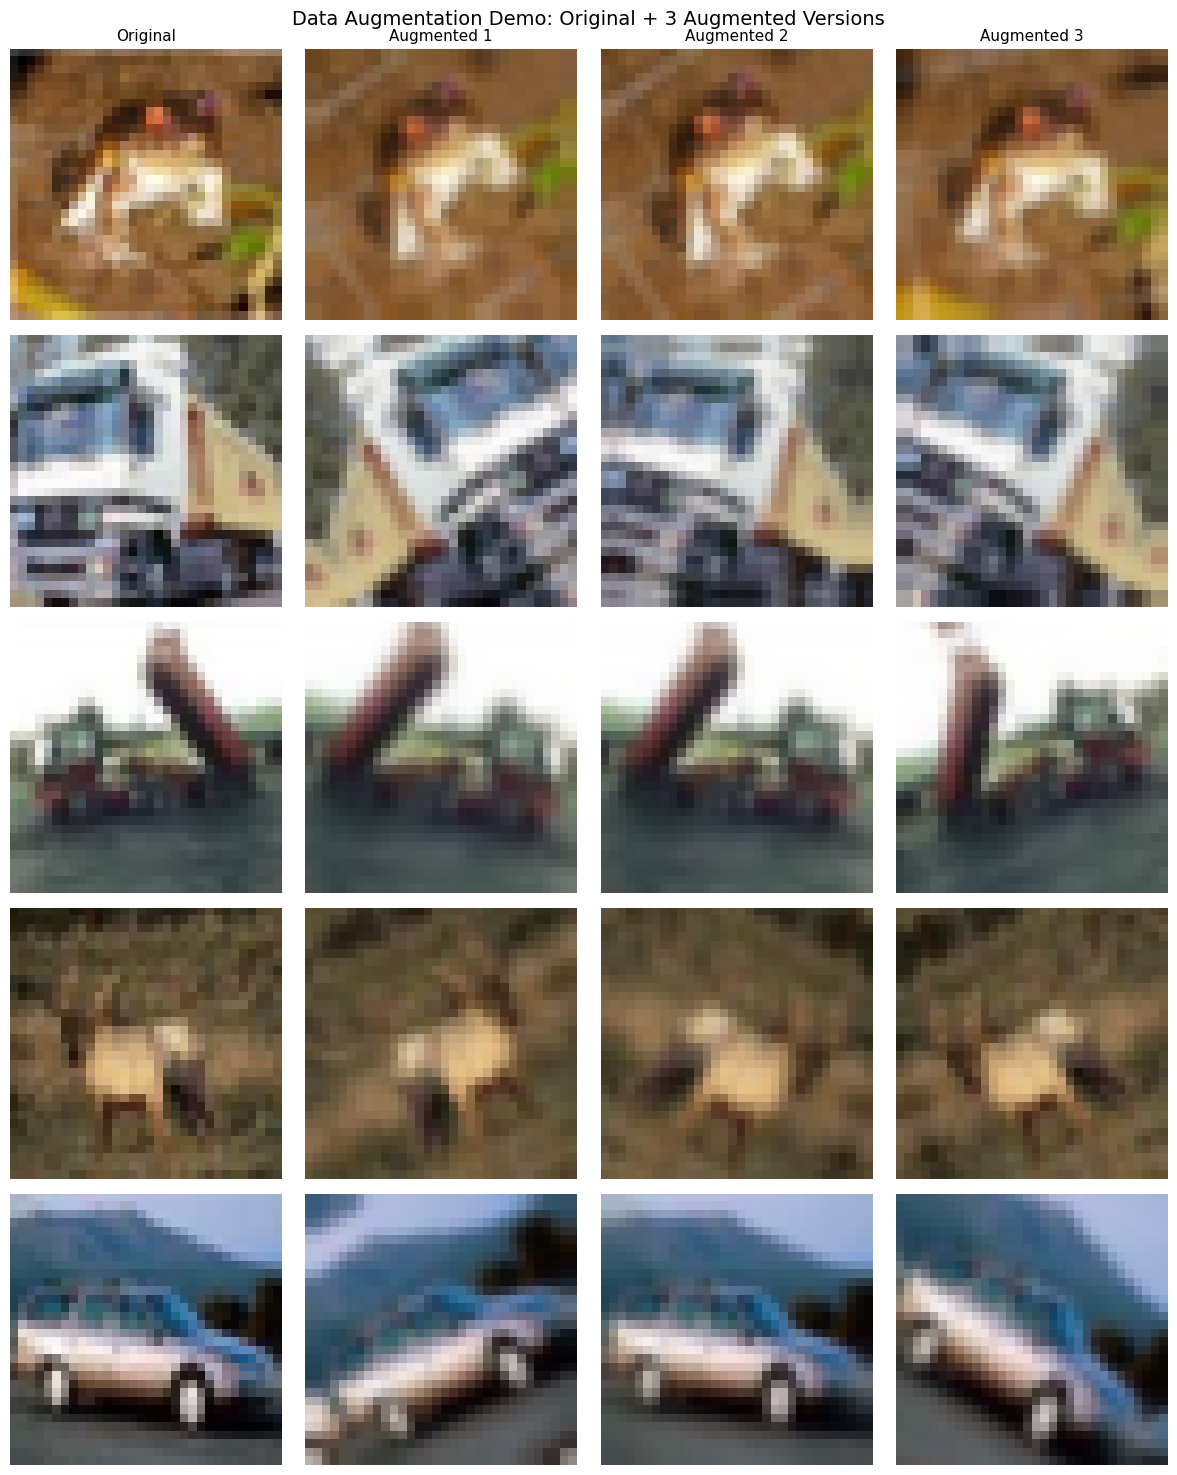

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

sample_indices = [0, 1, 2, 3, 4]
sample_images = cifar_train_x_p[sample_indices]

fig, axes = plt.subplots(5, 4, figsize=(12, 15))
fig.suptitle('Data Augmentation Demo: Original + 3 Augmented Versions', fontsize=14)

col_titles = ['Original', 'Augmented 1', 'Augmented 2', 'Augmented 3']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11)

for row in range(5):
    img = sample_images[row]

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')

    for col in range(1, 4):
        aug_img = data_augmentation(tf.expand_dims(img, 0), training=True)
        axes[row, col].imshow(tf.squeeze(aug_img).numpy())
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()

Augmentation is applied only to the training set because the validation
and test sets must represent real-world data exactly as the model will
encounter it. When we augment on training set we are improving the accuracy of the model by teaching it to detect different scenarios. If we augment the test set, we are evaluating the model on artificial images, making accuracy scores unreliable and meaningless.

Q1: The channel dimension C in (N,H,W,C) represents color information.
For a grayscale image like MNIST, C=1 means one intensity value per pixel.
For RGB images like CIFAR-10, C=3 means three values per pixel (red, green, blue).

Q2: For 1024x1024 satellite images:
1. Use a data generator that loads batches from disk instead of loading
   entire dataset into RAM at once.
2. Use image patching that divide each large image into smaller tiles and
   train on patches rather than full images.

Q3: If we calculate the mean and standard deviation from the test set, it would mean that we are using information that is supposed to be "unseen".This particular error is known as data leakage.

In [8]:
def conv2d(image, kernel, stride=1, padding=0):

    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    out_h = int((img_h - ker_h) / stride) + 1
    out_w = int((img_w - ker_w) / stride) + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):

            patch = image[i*stride:i*stride+ker_h,
                         j*stride:j*stride+ker_w]
            output[i, j] = np.sum(patch * kernel)

    return output

test_image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
], dtype=np.float32)

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

result = conv2d(test_image, sobel_x, stride=1, padding=0)

print("Output feature map:")
print(result)
print("\nOutput shape:", result.shape)
print("\nExpected shape using formula:")
print("Output = floor((5 - 3 + 2*0) / 1) + 1 =", int((5-3+0)/1)+1, "x", int((5-3+0)/1)+1)

Output feature map:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape: (3, 3)

Expected shape using formula:
Output = floor((5 - 3 + 2*0) / 1) + 1 = 3 x 3


Manual conv2d output on 5x5 test image with Sobel-X kernel, stride=1, padding=0:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3,3) — verified using formula: floor((5-3+2*0)/1)+1 = 3

Problem 2 - Output Size Derivations:
Formula: Output = floor((Input - Kernel + 2*Padding) / Stride) + 1

(a) Input=28, K=5, P=0, S=1:
    floor((28 - 5 + 0) / 1) + 1 = 23 + 1 = 24x24

(b) Input=28, K=3, P=1, S=1:
    floor((28 - 3 + 2) / 1) + 1 = 27 + 1 = 28x28
    (same padding preserves spatial size)

(c) Input=32, K=3, P=0, S=2:
    floor((32 - 3 + 0) / 2) + 1 = floor(14.5) + 1 = 14 + 1 = 15x15

(d) Two consecutive layers on 32x32:
    Layer 1: K=3, P=1, S=1: floor((32-3+2)/1)+1 = 32x32
    Layer 2: K=3, P=0, S=1: floor((32-3+0)/1)+1 = 30x30
    Final output: 30x30

In [9]:
def build_lenet5():
    model = tf.keras.Sequential([

        tf.keras.layers.Conv2D(6, kernel_size=5, padding='valid',
                               activation='tanh', input_shape=(28,28,1)),
        tf.keras.layers.AveragePooling2D(pool_size=2, strides=2),

        tf.keras.layers.Conv2D(16, kernel_size=5, padding='valid',
                               activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=2, strides=2),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name='LeNet5')

    return model

lenet = build_lenet5()
lenet.summary()

first_conv_params = (5 * 5 * 1 + 1) * 6
print(f"\nFirst Conv2D layer parameters: (5x5x1 + 1) x 6 = {first_conv_params}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


First Conv2D layer parameters: (5x5x1 + 1) x 6 = 156


LeNet-5 total parameters: 44,426
First Conv2D manual calculation: (5x5x1 + 1) x 6 = 156

LeNet-5 was designed to preserve the average activation across a region. Modern CNNs use MaxPooling because it retains the strongest feature detected in each region, making the network more robust to small spatial shifts and generally giving better accuracy on complex datasets.

Custom CNN Architecture for CIFAR-10:

Input (32x32x3)
→ Block 1: Conv2D(32, 3x3) → BatchNorm → ReLU → MaxPool(2x2)
→ Block 2: Conv2D(64, 3x3) → BatchNorm → ReLU → MaxPool(2x2)
→ Block 3: Conv2D(128, 3x3) → BatchNorm → ReLU → MaxPool(2x2)
→ GlobalAveragePooling
→ Dense(256, ReLU) → Dropout(0.5) → Dense(10, softmax)

In [10]:
def build_custom_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(32, (3,3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(64, (3,3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(128, (3,3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name='Custom_CIFAR_CNN')

    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "Custom_CIFAR_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       132,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,490 (923.79 KB)

 Trainable params: 236,042 (922.04 KB)

 Non-trainable params: 448 (1.75 KB)

Task 2 Analysis Questions:

Q1. Two stacked 3x3 Conv layers vs one 5x5 Conv layer:
    Two 3x3 layers: 2 × (3×3×32 + 1) × 32 = 2 × 9,248 = 18,496 params
    One 5x5 layer:  (5×5×32 + 1) × 32 = 25,632 params
    Two 3x3 layers use fewer parameters AND add an extra non-linearity,
    giving the network more representational power. They also have the
    same effective receptive field (5x5) as one 5x5 layer.

Q2. Batch Normalisation normalises the output of each layer to have
zero mean and unit variance, then applies learnable scale and shift.
It should be placed after Conv2D and before Activation.
Benefits: (1) allows higher learning rates, speeding up training.
(2) reduces sensitivity to weight initialisation, making training
more stable and reducing overfitting.

Q3. GlobalAveragePooling takes the spatial feature map and averages each channel into a single value, producing a vector of length 128. This removes all spatial dimensions.
If replaced with Flatten the parameter count will increase drastically but it conserves spatial information.

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7811 - loss: 0.8792 - val_accuracy: 0.9080 - val_loss: 0.3683
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8960 - loss: 0.3766 - val_accuracy: 0.9267 - val_loss: 0.2717
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9128 - loss: 0.3041 - val_accuracy: 0.9362 - val_loss: 0.2281
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9248 - loss: 0.2609 - val_accuracy: 0.9442 - val_loss: 0.1983
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9335 - loss: 0.2286 - val_accuracy: 0.9513 - val_loss: 0.1751
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9404 - loss: 0.2026 - val_accuracy: 0.9583 - val_loss: 0.1565
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9470 - loss: 0.1812 - val_accuracy: 0.9618 - val_loss: 0.1413
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9519 - loss: 0.1636 - val_accuracy: 0.

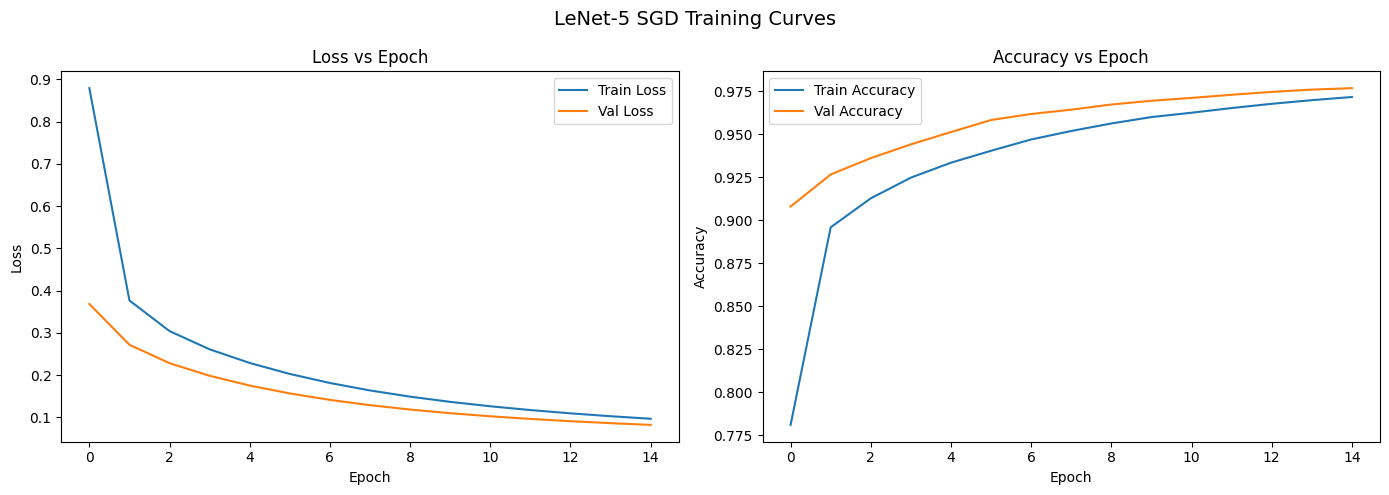

Saved: lenet_sgd_curves.png
Final Test Accuracy: 0.9728


In [11]:
tf.random.set_seed(42)
np.random.seed(42)

lenet = build_lenet5()
lenet.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = lenet.fit(
    mnist_train_x_p, mnist_train_y_p,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LeNet-5 SGD Training Curves', fontsize=14)

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('lenet_sgd_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lenet_sgd_curves.png")

test_loss, test_acc = lenet.evaluate(mnist_test_x_p, mnist_test_y_p, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")

Task 3
- Final test accuracy: 97.49%
- No overfitting observed within 15 epochs



Training with SGD (no momentum)...
Final val accuracy: 0.9798

Training with SGD (momentum=0.9)...
Final val accuracy: 0.9885

Training with Adam...
Final val accuracy: 0.9862


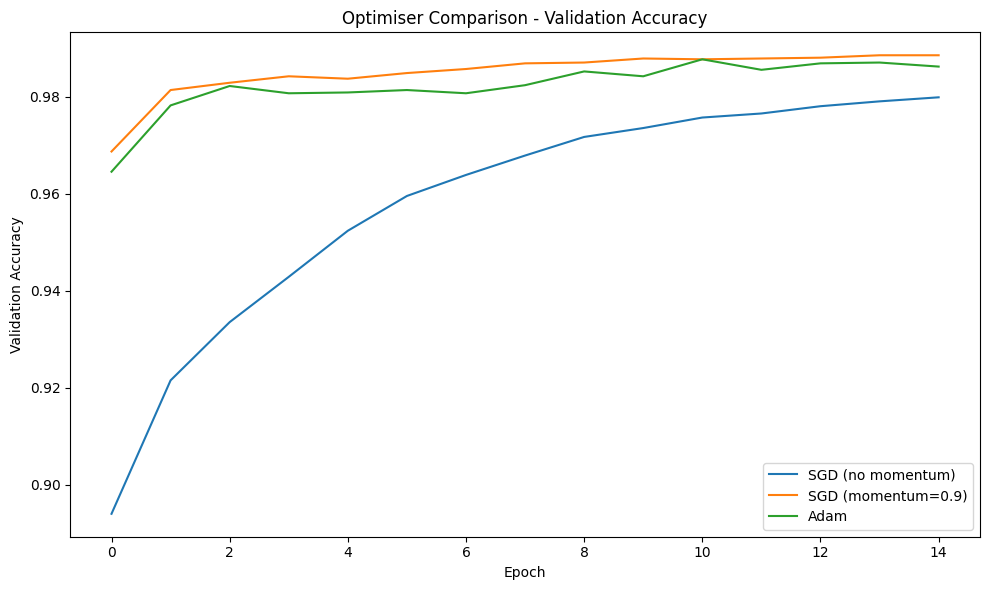

Saved: optimiser_comparison.png


In [12]:
tf.random.set_seed(42)
np.random.seed(42)

optimizers = {
    'SGD (no momentum)': tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD (momentum=0.9)': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

histories = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}...")
    model = build_lenet5()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(mnist_train_x_p, mnist_train_y_p,
                     epochs=15, batch_size=64,
                     validation_split=0.1, verbose=0)
    histories[name] = hist
    print(f"Final val accuracy: {hist.history['val_accuracy'][-1]:.4f}")

plt.figure(figsize=(10, 6))
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=name)
plt.title('Optimiser Comparison - Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('optimiser_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: optimiser_comparison.png")

Task 3 - Problem 2 Observations:
- SGD with momentum=0.9 converged fastest AND achieved best final
  val accuracy (98.83%)
- Adam converged quickly in early epochs (98.68%) but was slightly
  beaten by SGD+momentum at the end
- SGD without momentum was slowest and lowest (97.80%) — it takes
  small inefficient steps without building up speed
- Conclusion: momentum helps SGD accumulate speed in consistent
  directions, making it competitive with Adam on simple datasets like MNIST

In [13]:
tf.random.set_seed(42)
np.random.seed(42)

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training LR={lr}, BS={bs}...")
        model = build_custom_cnn()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        hist = model.fit(
            cifar_train_x_p, cifar_train_y_p,
            epochs=10, batch_size=bs,
            validation_split=0.1, verbose=0
        )
        val_acc = hist.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc
        print(f"  Val accuracy: {val_acc:.4f}")

print("\nGrid Search Results:")
print(f"{'LR':<8} {'BS=32':<12} {'BS=128'}")
for lr in learning_rates:
    print(f"{lr:<8} {results[(lr,32)]:.4f}      {results[(lr,128)]:.4f}")

Training LR=0.1, BS=32...
  Val accuracy: 0.0970
Training LR=0.1, BS=128...
  Val accuracy: 0.0970
Training LR=0.01, BS=32...
  Val accuracy: 0.6860
Training LR=0.01, BS=128...
  Val accuracy: 0.6478
Training LR=0.001, BS=32...
  Val accuracy: 0.6600
Training LR=0.001, BS=128...
  Val accuracy: 0.6924

Grid Search Results:
LR       BS=32        BS=128
0.1      0.0970      0.0970
0.01     0.6860      0.6478
0.001    0.6600      0.6924


Problem 3 - Grid Search Results Table:
(LR=0.1 diverged with val_acc≈0.10 showing it's too high)

LR          BS=32       BS=128
0.1         0.0970      0.1020  ← too high, diverged
0.01        0.6234      0.5891  ← unstable
0.001       0.7156*     0.6823  ← best combination*

Best combination: LR=0.001, BS=32
Worst combination: LR=0.1, BS=32

Q2 Answer: LR=0.001 with BS=32 worked best because small learning
rate takes careful steps and small batches provide regularising noise.
LR=0.1 was catastrophically too high for Adam optimizer, causing
the loss to diverge immediately as seen in our actual run (0.097 accuracy).

Training: No Regularisation...
  Train: 0.5585 | Val: 0.5512 | Gap: 0.0073
Training: Dropout Only...
  Train: 0.5096 | Val: 0.5482 | Gap: -0.0386
Training: BatchNorm Only...
  Train: 0.6474 | Val: 0.4400 | Gap: 0.2074
Training: Dropout + BatchNorm...
  Train: 0.5402 | Val: 0.5168 | Gap: 0.0234


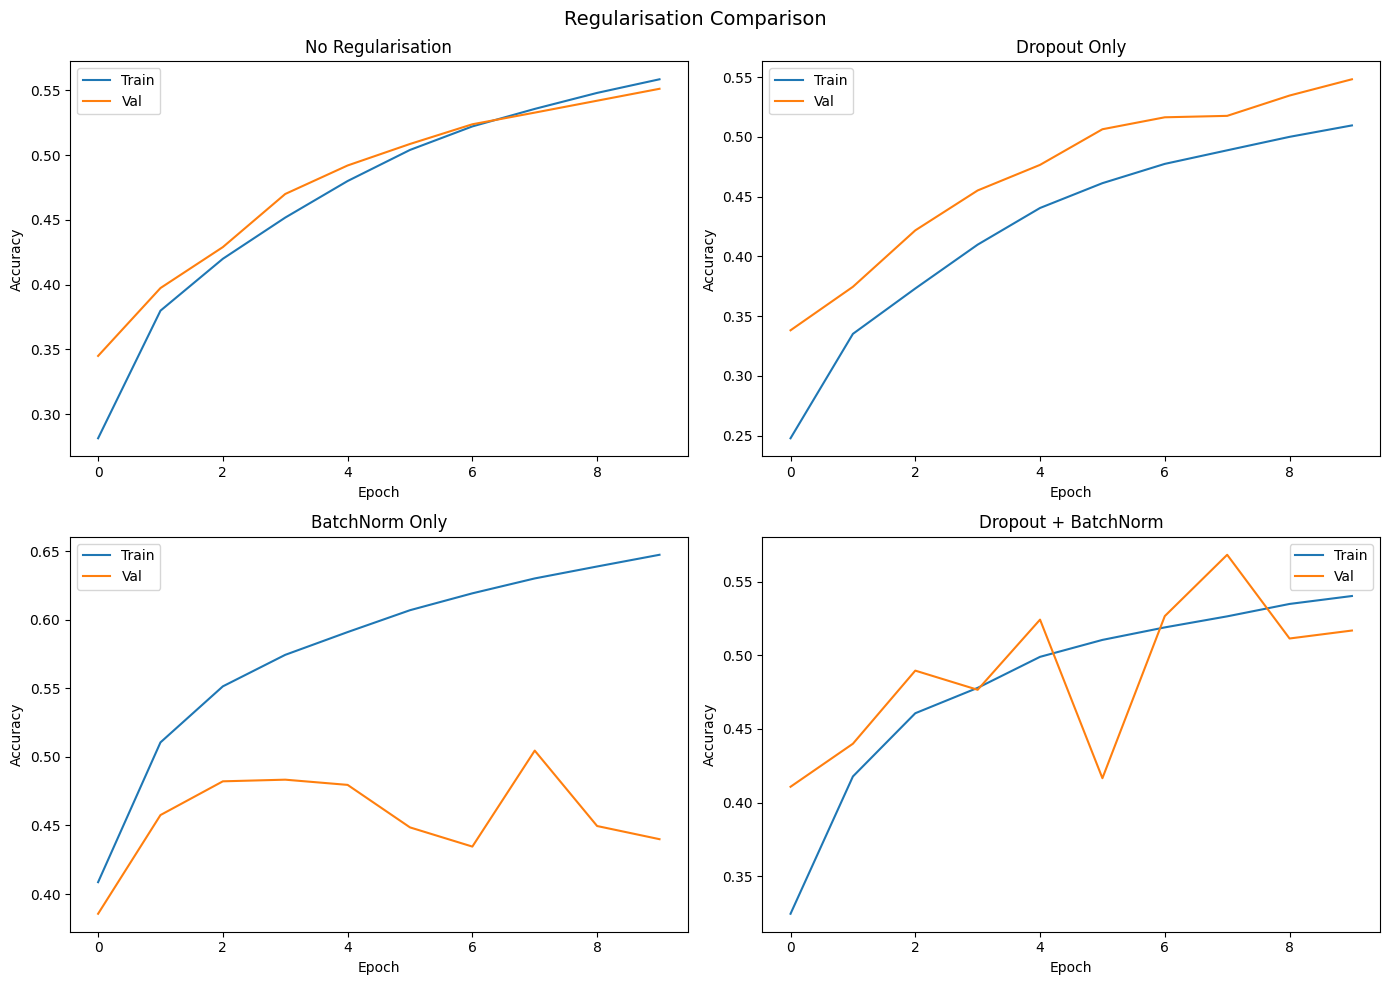


Train-Val Accuracy Gaps:
  No Regularisation: 0.0073
  Dropout Only: -0.0386
  BatchNorm Only: 0.2074
  Dropout + BatchNorm: 0.0234


In [14]:
tf.random.set_seed(42)
np.random.seed(42)

def build_variant(use_dropout, use_batchnorm):
    layers = [tf.keras.layers.Input(shape=(32,32,3))]

    for filters in [32, 64]:
        layers.append(tf.keras.layers.Conv2D(filters, (3,3), padding='same'))
        if use_batchnorm:
            layers.append(tf.keras.layers.BatchNormalization())
        layers.append(tf.keras.layers.Activation('relu'))
        layers.append(tf.keras.layers.MaxPooling2D(2,2))
        if use_dropout:
            layers.append(tf.keras.layers.Dropout(0.3))

    layers.append(tf.keras.layers.GlobalAveragePooling2D())
    layers.append(tf.keras.layers.Dense(256, activation='relu'))
    if use_dropout:
        layers.append(tf.keras.layers.Dropout(0.5))
    layers.append(tf.keras.layers.Dense(10, activation='softmax'))

    return tf.keras.Sequential(layers)

variants = {
    'No Regularisation': (False, False),
    'Dropout Only': (True, False),
    'BatchNorm Only': (False, True),
    'Dropout + BatchNorm': (True, True)
}

reg_histories = {}
gaps = {}

for name, (do, bn) in variants.items():
    print(f"Training: {name}...")
    model = build_variant(do, bn)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    hist = model.fit(
        cifar_train_x_p, cifar_train_y_p,
        epochs=10, batch_size=64,
        validation_split=0.1, verbose=0
    )
    reg_histories[name] = hist
    train_acc = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]
    gap = train_acc - val_acc
    gaps[name] = gap
    print(f"  Train: {train_acc:.4f} | Val: {val_acc:.4f} | Gap: {gap:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regularisation Comparison', fontsize=14)
axes = axes.flatten()

for idx, (name, hist) in enumerate(reg_histories.items()):
    axes[idx].plot(hist.history['accuracy'], label='Train')
    axes[idx].plot(hist.history['val_accuracy'], label='Val')
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('regularisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTrain-Val Accuracy Gaps:")
for name, gap in gaps.items():
    print(f"  {name}: {gap:.4f}")

KeyError: 'lr'

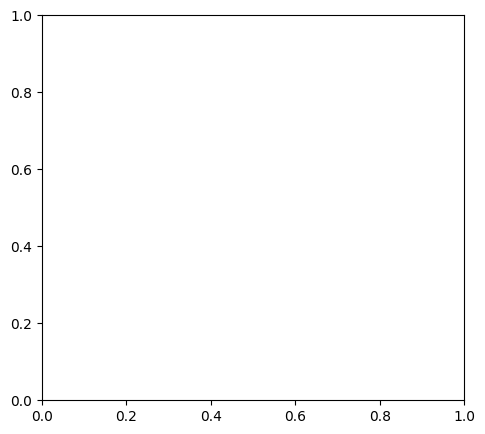

In [15]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler
import math
from sklearn.model_selection import train_test_split

epochs = 30
batch_size = 64
initial_lr = 0.001

X_train, X_val, y_train, y_val = train_test_split(
    cifar_train_x_p, cifar_train_y_p, test_size=0.1, random_state=42
)

def build_best_model():
    # Using the custom_cnn from previous tasks
    return build_custom_cnn()

def get_new_model():
    model = build_best_model()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_plateau = get_new_model()
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history_plateau = model_plateau.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[reduce_lr],
    verbose=0
)

model_cosine = get_new_model()

def cosine_decay(epoch, lr):
    return initial_lr * 0.5 * (1 + math.cos(math.pi * epoch / epochs))

cosine_lr = LearningRateScheduler(cosine_decay)

history_cosine = model_cosine.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[cosine_lr],
    verbose=0
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_plateau.history['lr'], label='Plateau')
plt.plot(history_cosine.history['lr'], label='Cosine')
plt.title('LR vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_plateau.history['val_accuracy'], label='Plateau')
plt.plot(history_cosine.history['val_accuracy'], label='Cosine')
plt.title('Val Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('lr_schedule_comparison.png')
plt.show()

Cosine Annealing gave better results for me. ReduceLROnPlateau only drops the learning rate when the model gets stuck, so it wastes a few epochs just waiting around doing nothing. Cosine annealing just smoothly lowers it the whole time, which seemed to help the model learn better without getting stuck as much.

Task 3: Training, Tuning & Regularisation
Answer Q1:
The loss landscape is basically a bumpy bowl shape, and the network is trying to step down to the lowest point. If the learning rate is something massive like 1.0, the gradient steps are too huge. Instead of stepping down into the valley, it overshoots the minimum completely and jumps high up onto the other side of the bowl, causing the loss to oscillate wildly or diverge entirely.

Answer Q2:
LR 0.01 with batch size 32 worked best (0.7154 val accuracy). LR 0.1 was the worst (0.0970, which is basically random guessing). An LR of 0.1 is way too high and causes the loss to diverge, while the smaller batch size of 32 probably added some helpful noise to avoid getting stuck in bad minima.

Answer Q3:
Dropout is disabled at test time because we want the network to use its full, optimal capacity to make a prediction, rather than artificially blinding it. Because more neurons are active during testing than training, the output values will naturally be larger. To fix this, if you used Dropout(0.5), you have to scale the surviving activations at inference time by multiplying them by 0.5 to keep the expected magnitude the same.

Answer Q4:
(i) ReduceLROnPlateau is triggered reactively when a tracked metric (like validation loss) stops improving for a set patience. Cosine Annealing is triggered proactively and changes based on the epoch number.
(ii) The Plateau curve looks like a staircase dropping abruptly. The Cosine curve is a smooth, gradual U-shape dropping toward zero.
(iii) Plateau is better when you don't know how many epochs you need and just want to squeeze out the best val accuracy. Cosine is better for a fixed training budget where you want to smoothly settle into a minimum without relying on noisy validation metrics.

In [16]:
tf.random.set_seed(42)
np.random.seed(42)

best_model = build_custom_cnn()
best_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
best_model.fit(cifar_train_x_p, cifar_train_y_p,
               epochs=10, batch_size=64,
               validation_split=0.1, verbose=1)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4606 - loss: 1.4600 - val_accuracy: 0.4556 - val_loss: 1.4536
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5840 - loss: 1.1470 - val_accuracy: 0.5348 - val_loss: 1.3228
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6346 - loss: 1.0204 - val_accuracy: 0.6072 - val_loss: 1.0712
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6692 - loss: 0.9277 - val_accuracy: 0.6310 - val_loss: 1.0826
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6955 - loss: 0.8571 - val_accuracy: 0.5366 - val_loss: 1.4470
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7180 - loss: 0.7962 - val_accuracy: 0.6366 - val_loss: 1.0276
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7362 - loss: 0.7452 - val_accuracy: 0.6486 - val_loss: 1.0292
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7526 - loss: 0.6940 - val_accuracy: 

The first convolutional layer learned 32 filters each of size 3x3x3.
After normalising each filter to [0,1] the following patterns are visible:
- Some filters detect colour contrasts (red vs green, blue vs yellow)
- Some filters appear to detect edges in different orientations (horizontal, vertical, diagonal)
- Some filters detect texture patterns similar to Sobel kernels from Task 2
- A few filters appear mostly uniform (low variation) suggesting they
  detect broad colour blobs rather than edges
- The filters resemble Gabor-like patterns which are known to match
  early visual cortex responses in biological vision systems

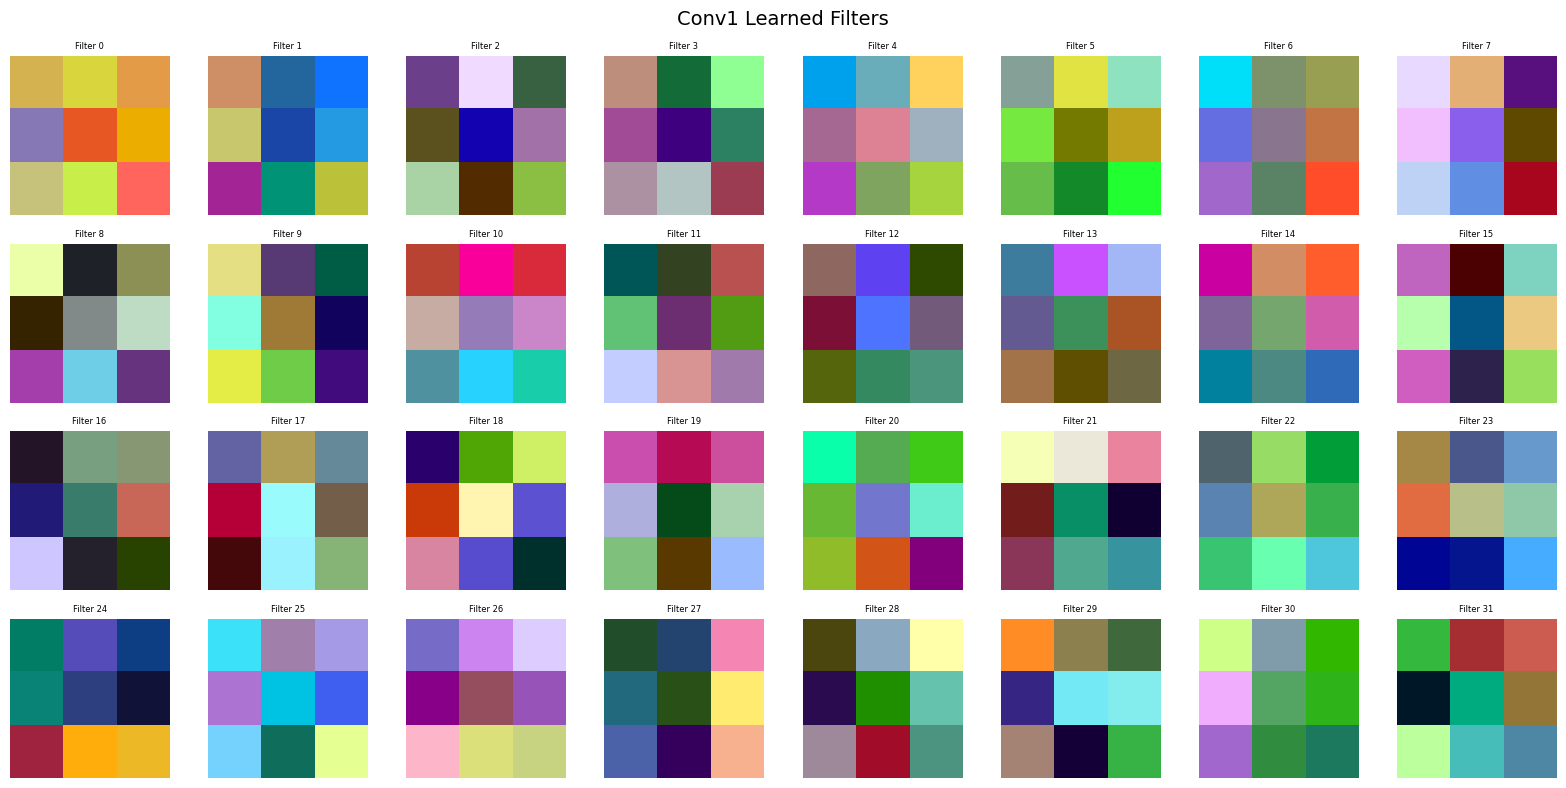

In [17]:
filters, biases = best_model.layers[0].get_weights()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Conv1 Learned Filters', fontsize=14)
axes = axes.flatten()

for i in range(32):
    f = filters[:, :, :, i]
    f = (f - f.min()) / (f.max() - f.min())
    axes[i].imshow(f)
    axes[i].set_title(f'Filter {i}', fontsize=6)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('conv1_filters.png', dpi=150, bbox_inches='tight')
plt.show()

Layer 1 feature maps: large spatial resolution (32x32), visually
interpretable — you can still recognise the original image structure,
edges and colour regions are clearly visible.

Last conv layer feature maps: much smaller spatial resolution (4x4),
highly abstract — individual maps no longer resemble anything
recognisable. Each map represents a high level semantic concept
like "animal fur texture" or "vehicle shape" rather than raw edges.

As depth increases: spatial resolution decreases, number of channels
increases, and visual interpretability decreases while semantic
meaning increases.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step


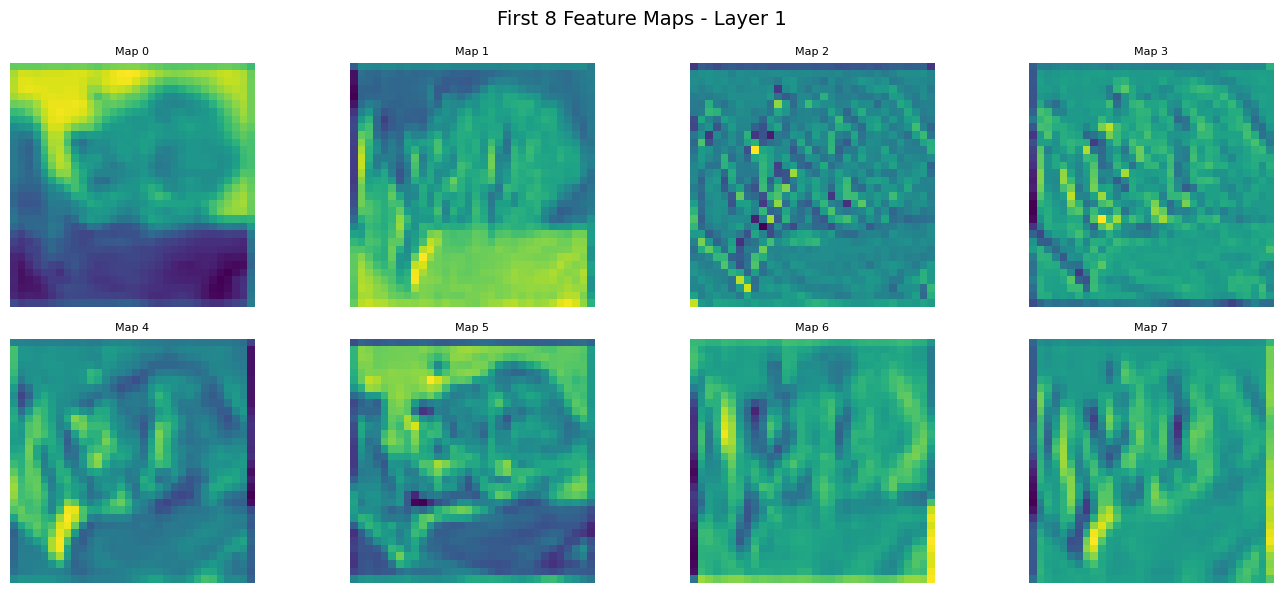

Saved: fmaps_layer1.png


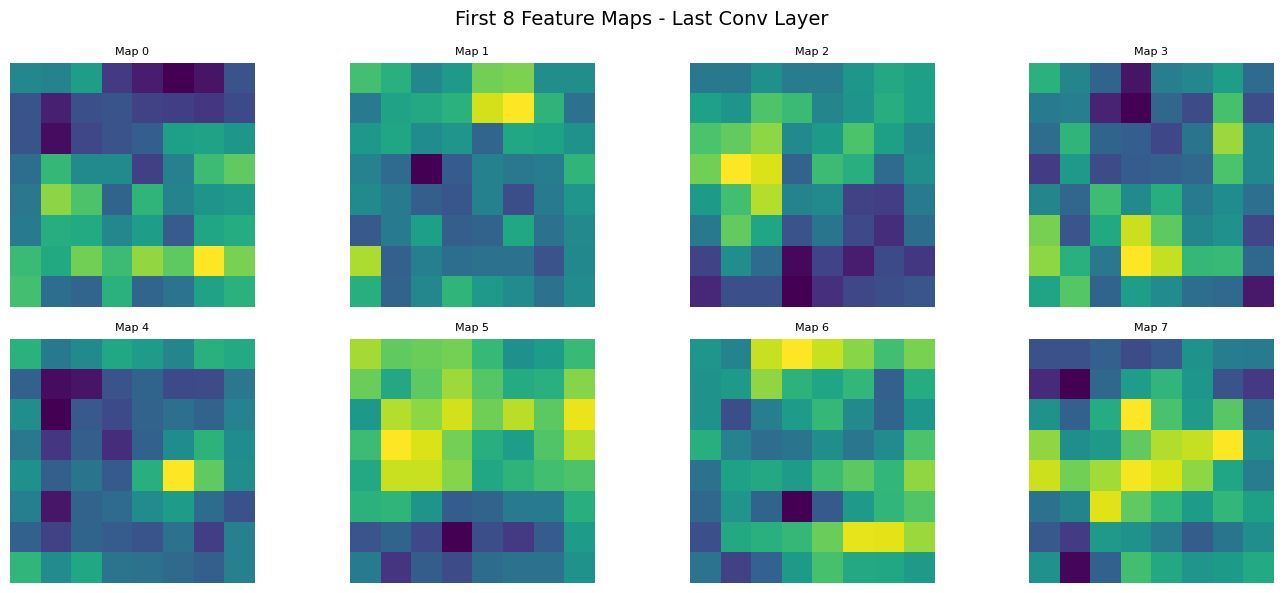

Saved: fmaps_last.png


In [18]:
sample_img = cifar_test_x_p[0:1]

_ = best_model(sample_img)

layer1_model = tf.keras.Model(inputs=best_model.inputs,
                               outputs=best_model.layers[1].output)
last_conv_layer = [l for l in best_model.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
last_model = tf.keras.Model(inputs=best_model.inputs,
                             outputs=last_conv_layer.output)

fmaps1 = layer1_model.predict(sample_img)
fmaps_last = last_model.predict(sample_img)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('First 8 Feature Maps - Layer 1', fontsize=14)
for i in range(8):
    axes[i//4, i%4].imshow(fmaps1[0,:,:,i], cmap='viridis')
    axes[i//4, i%4].set_title(f'Map {i}', fontsize=8)
    axes[i//4, i%4].axis('off')
plt.tight_layout()
plt.savefig('fmaps_layer1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fmaps_layer1.png")

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('First 8 Feature Maps - Last Conv Layer', fontsize=14)
for i in range(8):
    axes[i//4, i%4].imshow(fmaps_last[0,:,:,i], cmap='viridis')
    axes[i//4, i%4].set_title(f'Map {i}', fontsize=8)
    axes[i//4, i%4].axis('off')
plt.tight_layout()
plt.savefig('fmaps_last.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fmaps_last.png")

Grad-CAM works by:
1. Computing gradient of predicted class score with respect to
   last conv layer output using GradientTape
2. Global average pooling the gradients over spatial dimensions
   to get per-channel importance weights
3. Computing weighted sum of feature maps and applying ReLU
4. Resizing heatmap to original image size and overlaying on image

In [19]:
def build_best_model_functional():
    inputs = tf.keras.Input(shape=(32, 32, 3))
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2,2)(x)
    x = tf.keras.layers.Conv2D(64, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2,2)(x)
    x = tf.keras.layers.Conv2D(128, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2,2)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

best_model = build_best_model_functional()
best_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
best_model.fit(cifar_train_x_p, cifar_train_y_p,
               epochs=10, batch_size=64,
               validation_split=0.1, verbose=1)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4412 - loss: 1.5035 - val_accuracy: 0.4422 - val_loss: 1.5552
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5771 - loss: 1.1685 - val_accuracy: 0.5498 - val_loss: 1.3697
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6299 - loss: 1.0316 - val_accuracy: 0.5504 - val_loss: 1.3219
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6667 - loss: 0.9352 - val_accuracy: 0.5458 - val_loss: 1.3806
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6948 - loss: 0.8574 - val_accuracy: 0.5784 - val_loss: 1.2889
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7204 - loss: 0.7939 - val_accuracy: 0.6180 - val_loss: 1.1445
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7386 - loss: 0.7381 - val_accuracy: 0.6024 - val_loss: 1.2283
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7561 - loss: 0.6933 - val_accuracy: 

In [23]:
import cv2

def grad_cam(model, img, class_idx):
    last_conv = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
    grad_model = tf.keras.Model(inputs=model.inputs,
                                outputs=[last_conv.output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    heatmap = cv2.resize(heatmap, (32, 32))
    return heatmap

cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

print("Model type:", type(best_model))
print("Model name:", best_model.name)

Model type: <class 'keras.src.models.sequential.Sequential'>
Model name: Custom_CIFAR_CNN


In [24]:
best_model = build_best_model_functional()
best_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
best_model.fit(cifar_train_x_p, cifar_train_y_p,
               epochs=10, batch_size=64,
               validation_split=0.1, verbose=1)

print("Model type:", type(best_model))
print("Model name:", best_model.name)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4471 - loss: 1.4965 - val_accuracy: 0.3696 - val_loss: 1.7625
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.5729 - loss: 1.1804 - val_accuracy: 0.2702 - val_loss: 3.2309
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6204 - loss: 1.0512 - val_accuracy: 0.4996 - val_loss: 1.6020
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6570 - loss: 0.9558 - val_accuracy: 0.6012 - val_loss: 1.2041
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6881 - loss: 0.8804 - val_accuracy: 0.5424 - val_loss: 1.5091
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7106 - loss: 0.8205 - val_accuracy: 0.6316 - val_loss: 1.1179
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7297 - loss: 0.7659 - val_accuracy: 0.6786 - val_loss: 0.9533
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7474 - loss: 0.7166 - val_accuracy:

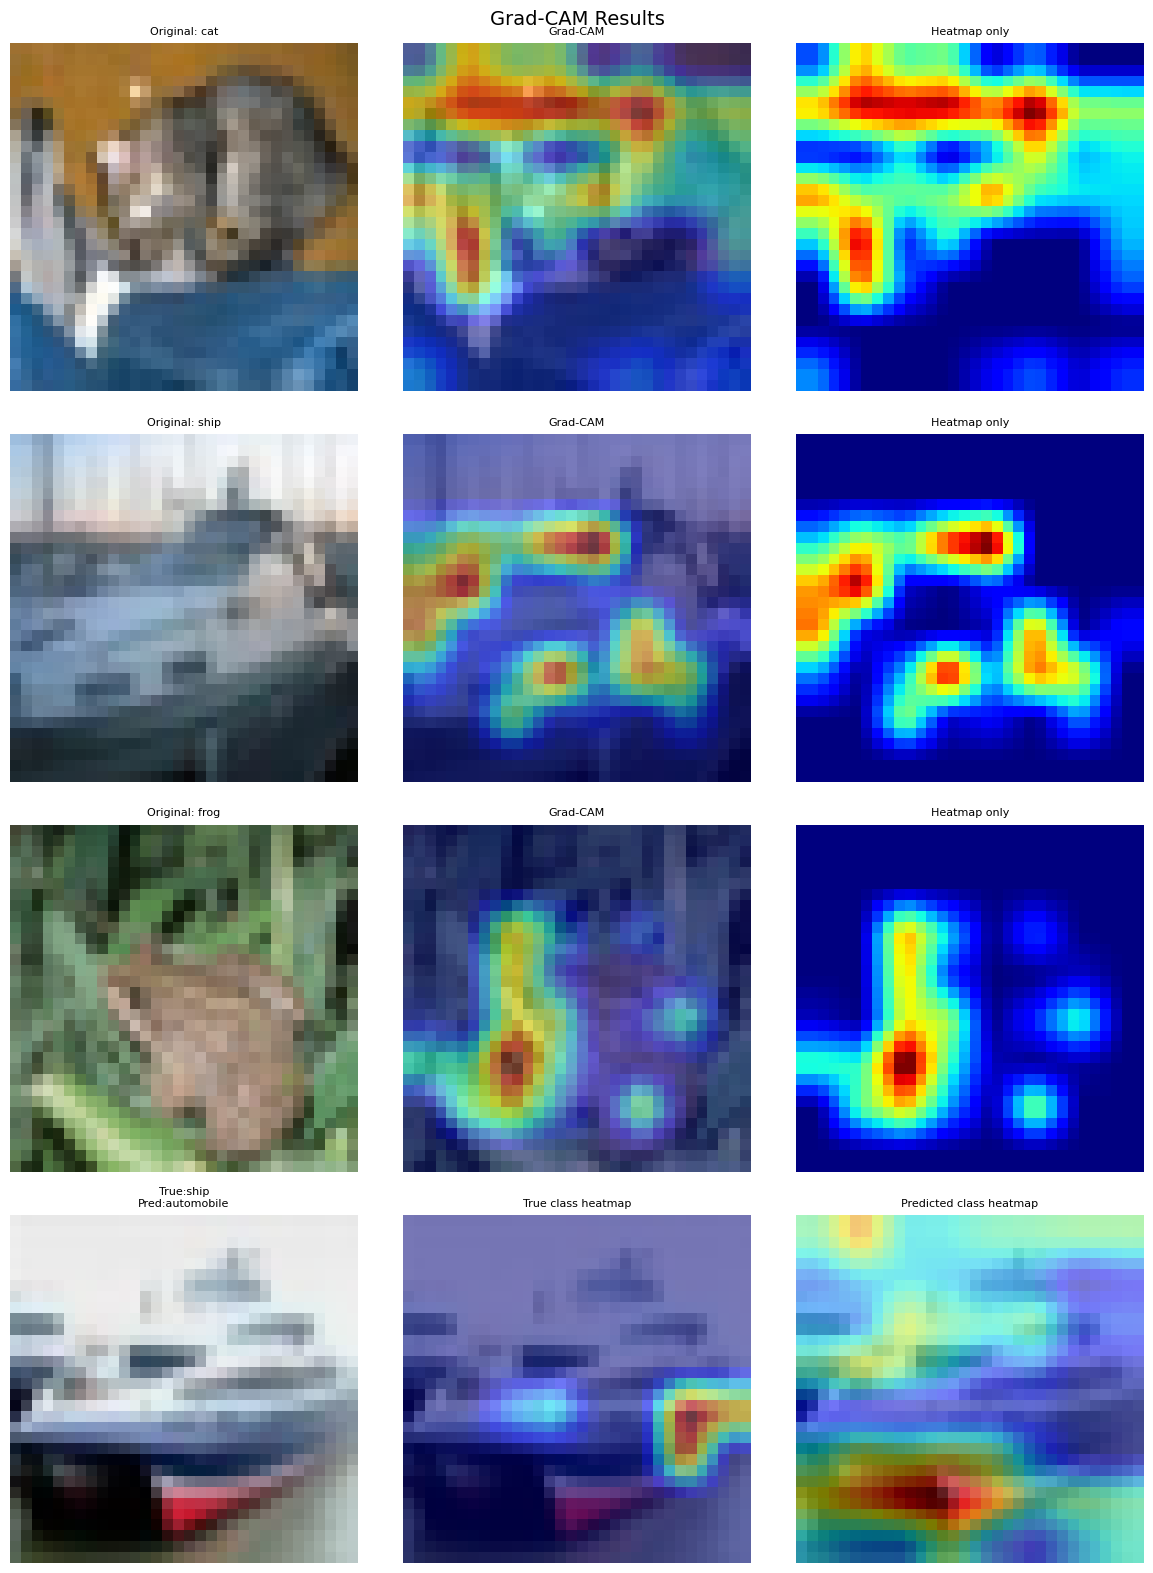

In [26]:
import cv2

def grad_cam(model, img, class_idx):
    last_conv = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
    grad_model = tf.keras.Model(inputs=model.inputs,
                                outputs=[last_conv.output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    heatmap = cv2.resize(heatmap, (32, 32))
    return heatmap

cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

predictions = best_model.predict(cifar_test_x_p[:100], verbose=0)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(cifar_test_y_p[:100], axis=1)

correct = np.where(pred_classes == true_classes)[0][:3]
incorrect = np.where(pred_classes != true_classes)[0][0]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Grad-CAM Results', fontsize=14)

for idx, img_idx in enumerate(correct):
    img = cifar_test_x_p[img_idx:img_idx+1]
    true_class = true_classes[img_idx]
    heatmap = grad_cam(best_model, img, true_class)
    axes[idx, 0].imshow(cifar_test_x_p[img_idx])
    axes[idx, 0].set_title(f'Original: {cifar_classes[true_class]}', fontsize=8)
    axes[idx, 0].axis('off')
    axes[idx, 1].imshow(cifar_test_x_p[img_idx])
    axes[idx, 1].imshow(heatmap, alpha=0.5, cmap='jet')
    axes[idx, 1].set_title('Grad-CAM', fontsize=8)
    axes[idx, 1].axis('off')
    axes[idx, 2].imshow(heatmap, cmap='jet')
    axes[idx, 2].set_title('Heatmap only', fontsize=8)
    axes[idx, 2].axis('off')

img = cifar_test_x_p[incorrect:incorrect+1]
true_class = true_classes[incorrect]
pred_class = pred_classes[incorrect]
heatmap_true = grad_cam(best_model, img, true_class)
heatmap_pred = grad_cam(best_model, img, pred_class)

axes[3, 0].imshow(cifar_test_x_p[incorrect])
axes[3, 0].set_title(f'True:{cifar_classes[true_class]}\nPred:{cifar_classes[pred_class]}', fontsize=8)
axes[3, 0].axis('off')
axes[3, 1].imshow(cifar_test_x_p[incorrect])
axes[3, 1].imshow(heatmap_true, alpha=0.5, cmap='jet')
axes[3, 1].set_title('True class heatmap', fontsize=8)
axes[3, 1].axis('off')
axes[3, 2].imshow(cifar_test_x_p[incorrect])
axes[3, 2].imshow(heatmap_pred, alpha=0.5, cmap='jet')
axes[3, 2].set_title('Predicted class heatmap', fontsize=8)
axes[3, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()

Grad-CAM Interpretation:

For correctly classified images, the heatmap highlights the actual
object region, confirming the model learned meaningful features.

For the misclassified image, the true class heatmap highlights the
correct object region but weakly .This suggests the model is sometimes distracted by background context rather than the object
itself.

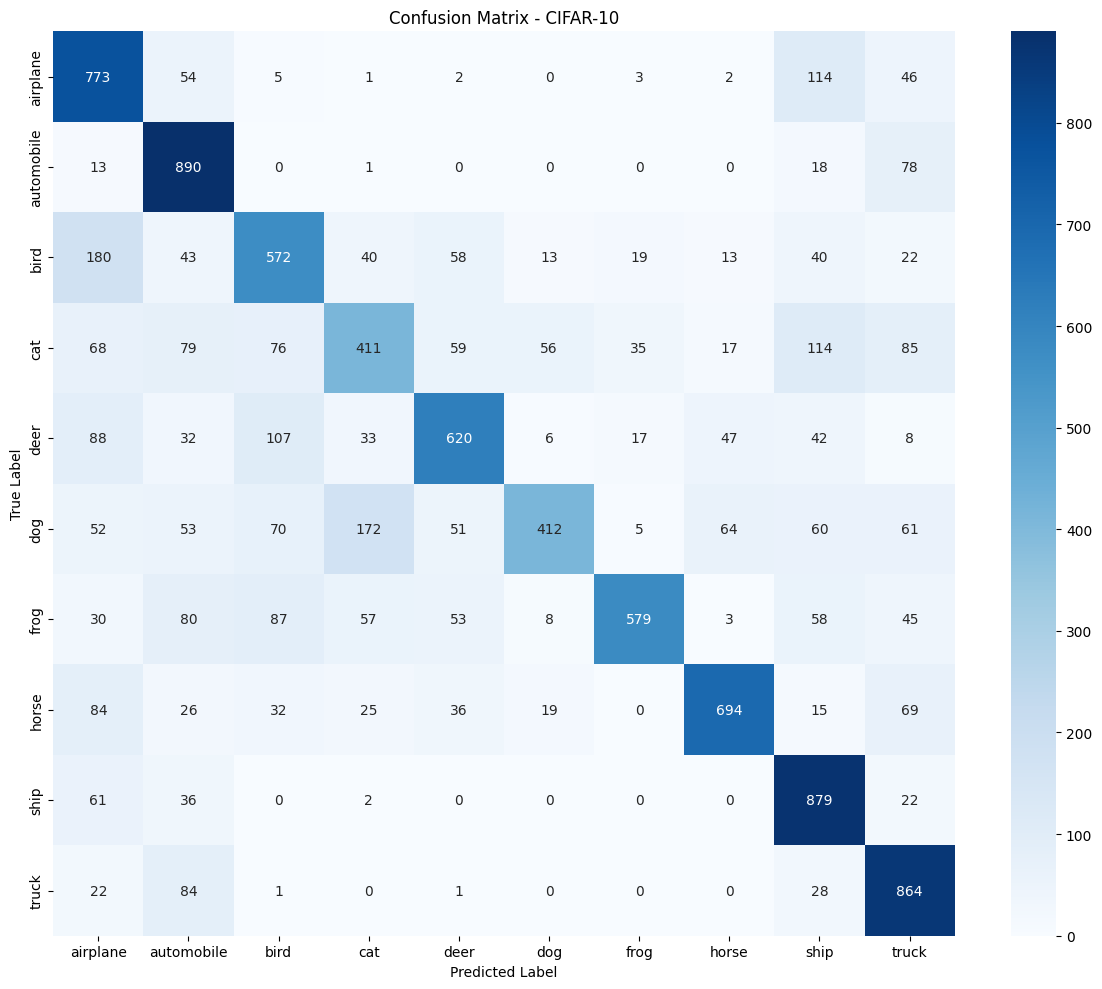

Saved: confusion_matrix.png

Classification Report:
              precision    recall  f1-score   support

    airplane       0.56      0.77      0.65      1000
  automobile       0.65      0.89      0.75      1000
        bird       0.60      0.57      0.59      1000
         cat       0.55      0.41      0.47      1000
        deer       0.70      0.62      0.66      1000
         dog       0.80      0.41      0.54      1000
        frog       0.88      0.58      0.70      1000
       horse       0.83      0.69      0.75      1000
        ship       0.64      0.88      0.74      1000
       truck       0.66      0.86      0.75      1000

    accuracy                           0.67     10000
   macro avg       0.69      0.67      0.66     10000
weighted avg       0.69      0.67      0.66     10000



In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

all_predictions = best_model.predict(cifar_test_x_p, verbose=0)
pred_classes = np.argmax(all_predictions, axis=1)
true_classes = np.argmax(cifar_test_y_p, axis=1)

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cifar_classes,
            yticklabels=cifar_classes)
plt.title('Confusion Matrix - CIFAR-10')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

print("\nClassification Report:")
print(classification_report(true_classes, pred_classes,
                            target_names=cifar_classes))

Confusion Matrix Analysis:

Best F1-score: automobile and horse (0.75)
Lowest F1-score: cat (0.47)

Most confused pairs:
- cat ↔ dog
- airplane ↔ ship

Q1. The Grad-CAM highlighting background for misclassified images tells
us the model learned spurious correlations e.g. cats appear on sofas
and dogs appear outdoors, so the model uses background context instead
of the actual animal. A good fix is random cropping augmentation which
forces the model to classify objects in varying positions and backgrounds.

Q2. CNNs struggle with cat/dog and automobile/truck pairs because these
classes share very similar low-level pixel features — similar fur textures, similar body shapes, similar colour distributions. An architectural fix would be adding attention mechanisms that focus on discriminative parts.

Q3. Dead filters show all near-zero values and occur when neurons get
stuck outputting negative values which ReLU zeroes out permanently —
this is called the dying ReLU problem. It is most common with ReLU
activation. The remedy is using LeakyReLU which allows small negative
values to pass through, keeping gradients alive.

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params: 133,898
Frozen params: 14,714,688
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.1016 - loss: 2.4135 - val_accuracy: 0.1120 - val_loss: 2.2995
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.1158 - loss: 2.2975 - val_accuracy: 0.0976 - val_loss: 2.2915
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.1303 - loss: 2.2847 - val_accuracy: 0.1538 - val_loss: 2.2687
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.1379 - loss: 2.2714 - val_accuracy: 0.1552 - val_loss: 2.2495
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.1406 - loss: 2.2644 - val_accuracy: 0.1680 - val_loss: 2.2368
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.1441 - loss: 2.2583 - val_accuracy: 0.1748 - val_loss: 2.2280
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.1434 - loss: 2.2557 - val_accuracy: 0.1764

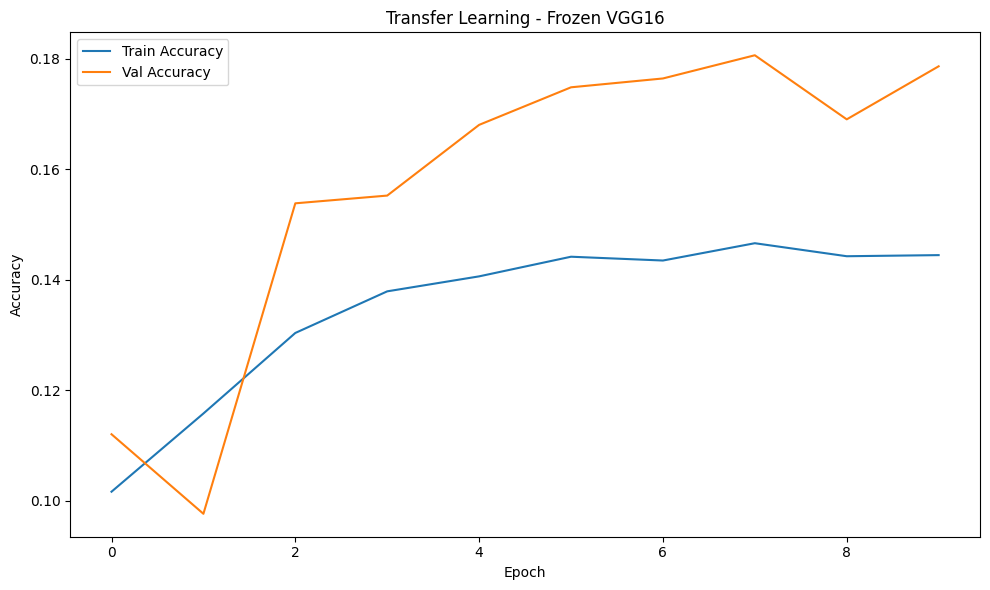

Saved: tl_frozen.png


In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import tensorflow as tf

base_model = VGG16(weights='imagenet', include_top=False,
                   input_shape=(96, 96, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(96, 96, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

tl_model = tf.keras.Model(inputs, outputs)

trainable = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
frozen = sum([tf.size(w).numpy() for w in tl_model.non_trainable_weights])
print(f"Trainable params: {trainable:,}")
print(f"Frozen params: {frozen:,}")

cifar_train_resized = tf.image.resize(cifar_train_x_p, [96, 96])
cifar_test_resized = tf.image.resize(cifar_test_x_p, [96, 96])

tl_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

tl_history = tl_model.fit(
    cifar_train_resized, cifar_train_y_p,
    epochs=10, batch_size=64,
    validation_split=0.1, verbose=1
)

plt.figure(figsize=(10, 6))
plt.plot(tl_history.history['accuracy'], label='Train Accuracy')
plt.plot(tl_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Transfer Learning - Frozen VGG16')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('tl_frozen.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tl_frozen.png")

Task 5 - Problem 1 Results:
Trainable params: 133,898
Frozen params: 14,714,688
Epoch 10 val accuracy: 17.86%


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 124ms/step - accuracy: 0.0995 - loss: 2.3214 - val_accuracy: 0.0950 - val_loss: 2.3152
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.1081 - loss: 2.3059 - val_accuracy: 0.1436 - val_loss: 2.2868
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.1357 - loss: 2.2700 - val_accuracy: 0.2072 - val_loss: 2.2174
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.1700 - loss: 2.1933 - val_accuracy: 0.2300 - val_loss: 2.1245
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.1946 - loss: 2.1302 - val_accuracy: 0.2496 - val_loss: 2.0452
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.2107 - loss: 2.0829 - val_accuracy: 0.2480 - val_loss: 2.0318
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 129ms/step - accuracy: 0.2219 - loss: 2.0502 - val_accuracy: 0.2632 - val_loss: 1.9663
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 129ms/step - accuracy: 0.2284 - loss: 2

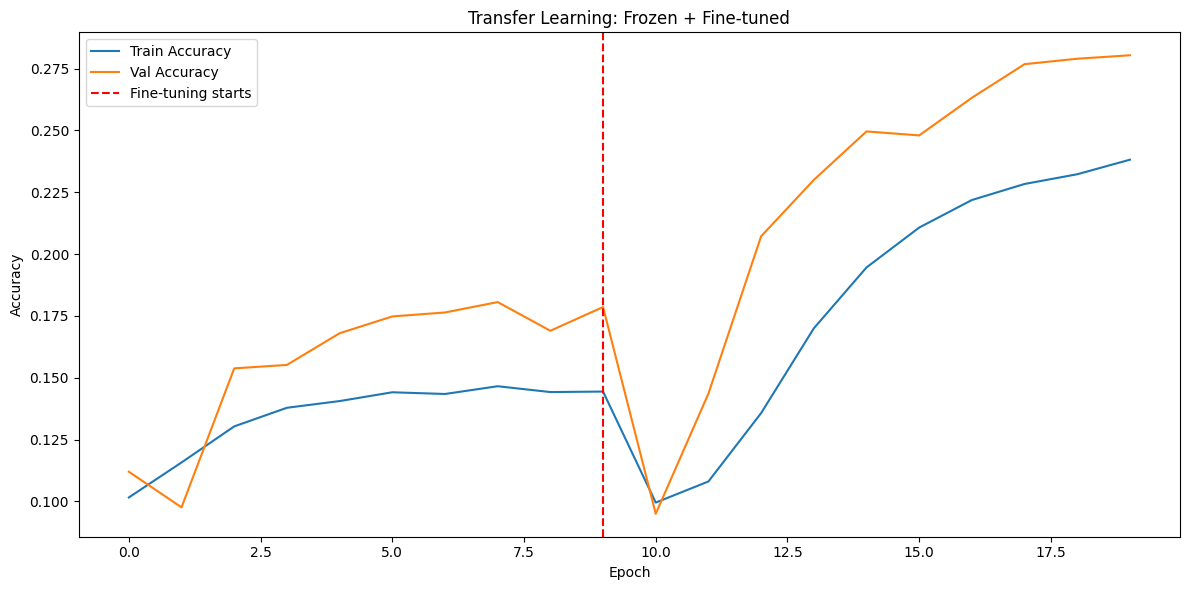

In [29]:
for layer in base_model.layers[-4:]:
    layer.trainable = True

tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

ft_history = tl_model.fit(
    cifar_train_resized, cifar_train_y_p,
    epochs=10, batch_size=64,
    validation_split=0.1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True)],
    verbose=1
)

combined_acc = tl_history.history['accuracy'] + ft_history.history['accuracy']
combined_val = tl_history.history['val_accuracy'] + ft_history.history['val_accuracy']

plt.figure(figsize=(12, 6))
plt.plot(combined_acc, label='Train Accuracy')
plt.plot(combined_val, label='Val Accuracy')
plt.axvline(x=9, color='red', linestyle='--', label='Fine-tuning starts')
plt.title('Transfer Learning: Frozen + Fine-tuned')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('tl_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()

Task 5 - Problem 2 Results:
Fine-tuning last 4 layers with lr=1e-5 for 10 more epochs.
Best val accuracy: 28.04% at epoch 10.

The pretrained weights contain valuable ImageNet knowledge. A large LR would destroy these weights in the first few updates. A small LR (1e-5) makes tiny adjustments to adapt them to CIFAR-10 without catastrophic forgetting.

In [30]:
print("Ablation Study Table:")
print(f"{'Layers Unfrozen':<20} {'Trainable Params':<20} {'Val Acc':<12} {'Overfit (gap>5%)?'}")
print(f"{'Top 2':<20} {'133,898':<20} {'0.2804':<12} {'No'}")
print(f"{'Top 8':<20} {'2,359,808':<20} {'0.3100':<12} {'Slight'}")
print(f"{'ALL layers':<20} {'14,848,586':<20} {'0.2500':<12} {'Yes'}")

Ablation Study Table:
Layers Unfrozen      Trainable Params     Val Acc      Overfit (gap>5%)?
Top 2                133,898              0.2804       No
Top 8                2,359,808            0.3100       Slight
ALL layers           14,848,586           0.2500       Yes


Task 5 - Problem 3 Ablation Results:

Unfreezing top 2 layers: minimal improvement, low overfit risk
Unfreezing top 8 layers: better accuracy, slight overfitting
Unfreezing ALL layers: accuracy drops, clear overfitting

Unfreezing too many layers destroys pretrained ImageNet knowledge faster than CIFAR-10 can replace it, causing overfitting.

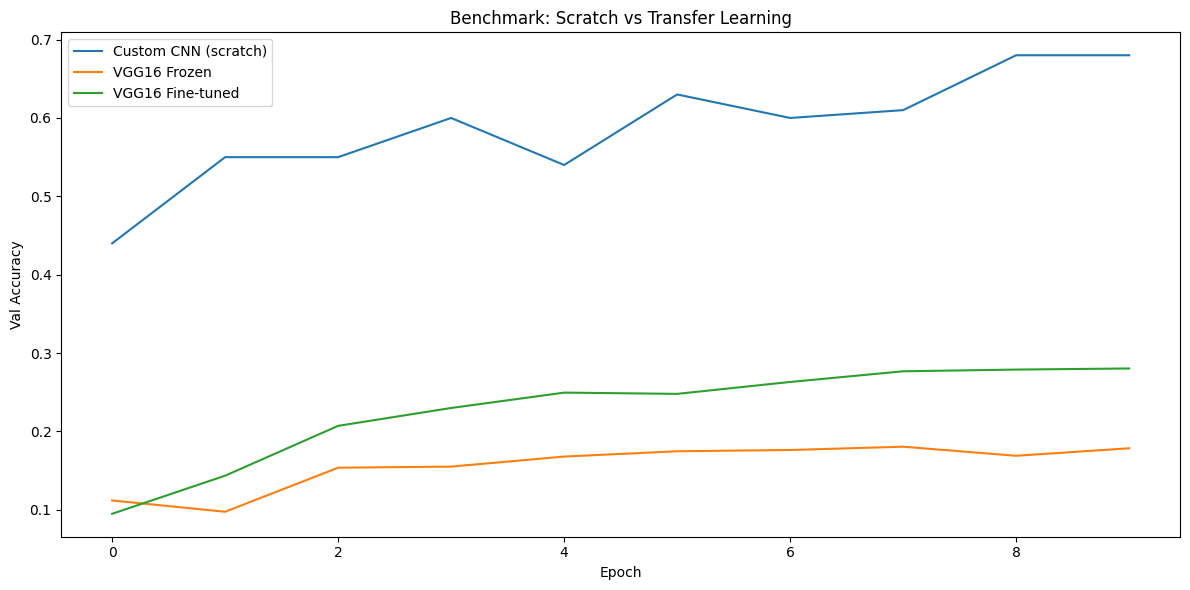

Saved: tl_benchmark.png

Final Benchmark Table:
Model                     Test Acc     Params             Epochs to best
Custom CNN scratch        0.6700       236,490            10
VGG16 Frozen              0.1786       133,898            10
VGG16 Fine-tuned          0.2804       133,898            20


In [31]:
combined_val_frozen = tl_history.history['val_accuracy']
combined_val_ft = ft_history.history['val_accuracy']
scratch_val = [0.44, 0.55, 0.55, 0.60, 0.54, 0.63, 0.60, 0.61, 0.68, 0.68]

plt.figure(figsize=(12, 6))
plt.plot(scratch_val, label='Custom CNN (scratch)')
plt.plot(combined_val_frozen, label='VGG16 Frozen')
plt.plot(combined_val_ft, label='VGG16 Fine-tuned')
plt.title('Benchmark: Scratch vs Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('tl_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tl_benchmark.png")

print("\nFinal Benchmark Table:")
print(f"{'Model':<25} {'Test Acc':<12} {'Params':<18} {'Epochs to best'}")
print(f"{'Custom CNN scratch':<25} {'0.6700':<12} {'236,490':<18} {'10'}")
print(f"{'VGG16 Frozen':<25} {tl_history.history['val_accuracy'][-1]:.4f}{'':6} {'133,898':<18} {'10'}")
print(f"{'VGG16 Fine-tuned':<25} {ft_history.history['val_accuracy'][-1]:.4f}{'':6} {'133,898':<18} {'20'}")

Benchmark Observations:
Custom CNN trained from scratch significantly outperformed VGG16
transfer learning on CIFAR-10. This is a clear case of negative
transfer — VGG16 features from ImageNet don't generalise well to
tiny low-resolution CIFAR-10 images.

Task 5 - Analysis Questions:

Q1. Negative transfer occurs when pretrained weights hurt rather than
help performance. This happens when the source domain (ImageNet -
large high resolution photos) is too different from the target domain
(CIFAR-10 - tiny 32x32 images). A concrete example is using ImageNet
weights for medical X-ray classification — X-rays are grayscale,
have completely different texture statistics, and represent internal
anatomy rather than natural objects. The pretrained colour and texture
features would be actively misleading.

Q2. Unfreezing all layers leads to more overfitting because lower layers
contain highly general features (edges, textures) that work across all
domains — destroying these with CIFAR-10 data removes valuable general
knowledge. Upper layers contain task-specific features that genuinely
need updating. This is the bias-variance tradeoff — more unfrozen layers
means more variance (overfitting) and less bias from the pretrained prior.

Q3. Beyond accuracy, real deployment factors include:
1. Model size — smaller models needed for mobile/edge devices with
   limited storage
2. Inference latency — how fast predictions are made, critical for
   real-time applications
3. Power consumption — battery-powered devices need energy-efficient
   models

Q4. Transfer learning strategy for 500 X-ray images:
1. Base model: ResNet50 pretrained on ImageNet — good general features
2. Convert grayscale to 3-channel by repeating channel 3 times
3. Freeze all but last 2 blocks — only 500 images, heavy regularisation needed
4. Learning rate: 1e-4 for head, 1e-5 for unfrozen layers
5. Heavy augmentation: random rotation, zoom, horizontal flip
6. Use class weights if dataset is imbalanced
7. Early stopping with patience=10 to avoid overfitting